## 네이버 영화리뷰 감성분석 프로젝트

### 활용 데이터셋
- [Naver Sentiment Movie Corpus(NSMC)](https://github.com/e9t/nsmc)
- 네이버 영화 댓글 기반, 긍정(1)/부정(0) 라벨

### 환경 설정 및 라이브러리 불러오기

In [1]:
# 필요한 라이브러리 설치 (최초 1회)
# !pip install konlpy gensim==4.3.2
# !pip install scipy==1.12.0 numpy==1.26.3

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from konlpy.tag import Mecab
from gensim.models import Word2Vec as GensimWord2Vec
from gensim.models.keyedvectors import Word2VecKeyedVectors

# 재현성을 위한 시드 고정
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# GPU 사용 가능 여부 확인
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 디바이스: {device}')

사용 디바이스: cuda


In [3]:
!sudo apt-get update -qq
!sudo apt-get install -qq fonts-nanum

import matplotlib.pyplot as plt

import matplotlib.font_manager as fm
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rc('font', family='NanumGothic')

### 데이터 준비와 확인

In [4]:
# NSMC 데이터셋 다운로드 (최초 1회)
# !wget https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt
# !wget https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt
# !mv ratings_*.txt ~/work/sentiment_classification/data/

In [5]:
# 데이터 읽기
data_dir = os.path.join(os.getenv('HOME'), 'work/sentiment_classification/data/')
train_data = pd.read_table(data_dir + 'ratings_train.txt')
test_data = pd.read_table(data_dir + 'ratings_test.txt')

print(f'훈련 데이터 크기: {train_data.shape}')
print(f'테스트 데이터 크기: {test_data.shape}')
train_data.head()

훈련 데이터 크기: (150000, 3)
테스트 데이터 크기: (50000, 3)


,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


In [6]:
# 라벨 분포 확인 (긍정/부정 균형)
print('=== 훈련 데이터 라벨 분포 ===')
print(train_data['label'].value_counts())
print(f'\n결측치 수: {train_data.isnull().sum()}')
print(f'중복 문서 수: {train_data["document"].duplicated().sum()}')

=== 훈련 데이터 라벨 분포 ===
label
0    75173
1    74827
Name: count, dtype: int64

결측치 수: id          0
document    5
label       0
dtype: int64
중복 문서 수: 3817


### 데이터 로더 구성

In [7]:
# 형태소 분석기 초기화 및 불용어 리스트 정의
tokenizer = Mecab()
stopwords = ['의', '가', '이', '은', '들', '는', '좀', '잘',
             '걍', '과', '도', '를', '으로', '자', '에', '와', '한', '하다']


def load_data(train_data, test_data, num_words=10000):
    '''
    NSMC 데이터를 전처리하여 모델 학습에 사용할 수 있는 형태로 변환
    
    수행 작업:
    1) 중복 제거 및 결측치 제거
    2) Mecab 형태소 분석기로 토큰화
    3) 불용어 제거
    4) 빈도 기반 단어 사전 구성 (상위 num_words개)
    5) 텍스트 → 정수 인덱스 변환
    
    Returns:
        X_train, y_train, X_test, y_test, word_to_index
    '''
    # --- 1) 중복 제거 & 결측치 제거 ---
    train_data = train_data.drop_duplicates(subset=['document'])
    train_data = train_data.dropna(how='any')
    test_data = test_data.drop_duplicates(subset=['document'])
    test_data = test_data.dropna(how='any')
    print(f'전처리 후 훈련 데이터: {len(train_data)}건, 테스트 데이터: {len(test_data)}건')

    # --- 2~3) 토큰화 + 불용어 제거 ---
    X_train = []
    for sentence in train_data['document']:
        temp_X = tokenizer.morphs(str(sentence))  # 형태소 단위 토큰화
        temp_X = [word for word in temp_X if word not in stopwords]  # 불용어 제거
        X_train.append(temp_X)

    X_test = []
    for sentence in test_data['document']:
        temp_X = tokenizer.morphs(str(sentence))
        temp_X = [word for word in temp_X if word not in stopwords]
        X_test.append(temp_X)

    # --- 4) 단어 사전 구성 ---
    # 훈련 데이터의 모든 토큰을 하나의 리스트로 합침
    words = np.concatenate(X_train).tolist()
    counter = Counter(words)
    # 상위 num_words-4개 (특수 토큰 4개를 제외한 만큼)
    counter = counter.most_common(num_words - 4)
    # 특수 토큰: PAD(0), BOS(1), UNK(2), UNUSED(3)
    vocab = ['<PAD>', '<BOS>', '<UNK>', '<UNUSED>'] + [key for key, _ in counter]
    word_to_index = {word: index for index, word in enumerate(vocab)}
    print(f'사전 크기: {len(word_to_index)}')

    # --- 5) 텍스트 → 정수 인덱스 변환 ---
    def wordlist_to_indexlist(wordlist):
        return [word_to_index[word] if word in word_to_index
                else word_to_index['<UNK>'] for word in wordlist]

    X_train = list(map(wordlist_to_indexlist, X_train))
    X_test = list(map(wordlist_to_indexlist, X_test))

    return X_train, np.array(list(train_data['label'])), \
           X_test, np.array(list(test_data['label'])), word_to_index

In [8]:
# 데이터 로드 및 전처리 실행
X_train, y_train, X_test, y_test, word_to_index = load_data(train_data, test_data)

# 역방향 사전 (인덱스 → 단어) 생성
index_to_word = {index: word for word, index in word_to_index.items()}

전처리 후 훈련 데이터: 146182건, 테스트 데이터: 49157건
사전 크기: 10000


In [9]:
# 전처리 결과 샘플 확인
print('=== 인코딩된 첫 번째 리뷰 (정수 인덱스) ===')
print(X_train[0][:20], '...')
print(f'\n=== 디코딩된 첫 번째 리뷰 (텍스트) ===')
print(' '.join([index_to_word.get(idx, '<UNK>') for idx in X_train[0]]))
print(f'라벨: {y_train[0]}')

=== 인코딩된 첫 번째 리뷰 (정수 인덱스) ===
[32, 74, 939, 4, 4, 39, 229, 20, 33, 747] ...

=== 디코딩된 첫 번째 리뷰 (텍스트) ===
아 더 빙 . . 진짜 짜증 나 네요 목소리
라벨: 0


### 데이터 분석 및 가공

In [10]:
# --- 문장 길이 분포 분석 ---
total_data = X_train + X_test
num_tokens = np.array([len(tokens) for tokens in total_data])

print(f'문장 길이 평균: {np.mean(num_tokens):.2f}')
print(f'문장 길이 최대: {np.max(num_tokens)}')
print(f'문장 길이 표준편차: {np.std(num_tokens):.2f}')

# 최대 길이 = 평균 + 2*표준편차 (약 95% 커버)
max_tokens = np.mean(num_tokens) + 2 * np.std(num_tokens)
maxlen = int(max_tokens)
coverage = np.sum(num_tokens < max_tokens) / len(num_tokens) * 100
print(f'\npad_sequences maxlen: {maxlen}')
print(f'전체 문장의 {coverage:.2f}%가 maxlen 이내에 포함됩니다.')

문장 길이 평균: 15.97
문장 길이 최대: 116
문장 길이 표준편차: 12.84

pad_sequences maxlen: 41
전체 문장의 93.43%가 maxlen 이내에 포함됩니다.


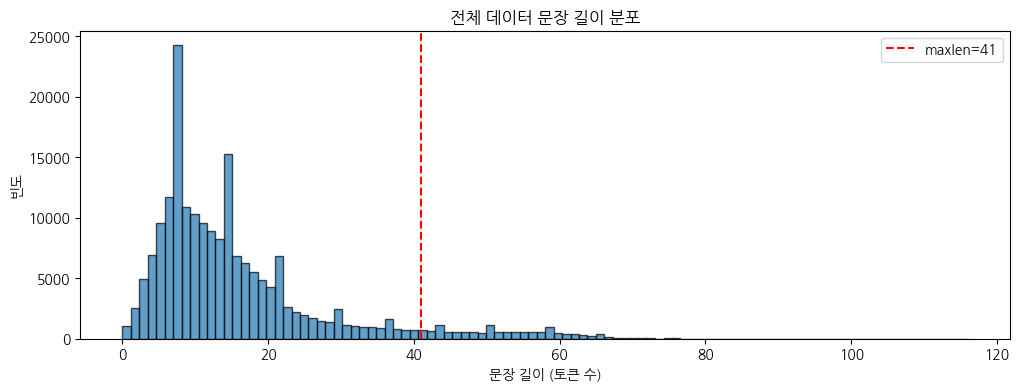

In [11]:
# 문장 길이 분포 시각화
plt.figure(figsize=(12, 4))
plt.hist(num_tokens, bins=100, edgecolor='black', alpha=0.7)
plt.axvline(x=maxlen, color='red', linestyle='--', label=f'maxlen={maxlen}')
plt.xlabel('문장 길이 (토큰 수)')
plt.ylabel('빈도')
plt.title('전체 데이터 문장 길이 분포')
plt.legend()
plt.show()

In [12]:
# 토큰 개수가 80개를 넘는 리뷰가 몇 개나 되는지 확인
over_80 = [n for n in num_tokens if n > 80]
print(f"80개 초과 리뷰 개수: {len(over_80)}개")
print(f"전체 대비 비율: {len(over_80) / len(num_tokens) * 100:.2f}%")

80개 초과 리뷰 개수: 17개
전체 대비 비율: 0.01%


In [13]:
# --- 패딩 함수 정의 ---
# RNN 계열에는 'pre' 패딩이, CNN 계열에는 'post' 패딩이 일반적으로 유리
# 그래서, 두 가지 모두 준비

def pad_sequences(data, maxlen, padding='pre'):
    '''
    문장을 maxlen 길이로 맞춰주는 패딩 함수.
    padding='pre': 앞쪽에 0을 채움 (RNN에 유리)
    padding='post': 뒤쪽에 0을 채움 (CNN에 유리)
    '''
    padded = []
    for seq in data:
        if len(seq) >= maxlen:
            padded.append(seq[:maxlen])   # 긴 문장은 잘라냄
        else:
            pad_len = maxlen - len(seq)
            if padding == 'pre':
                padded.append([0] * pad_len + seq)   # 앞쪽 패딩
            else:
                padded.append(seq + [0] * pad_len)   # 뒤쪽 패딩
    return np.array(padded)


# 'pre' 패딩 (RNN용) 과 'post' 패딩 (CNN용) 모두 생성
X_train_pre = pad_sequences(X_train, maxlen, padding='pre')
X_test_pre  = pad_sequences(X_test, maxlen, padding='pre')

X_train_post = pad_sequences(X_train, maxlen, padding='post')
X_test_post  = pad_sequences(X_test, maxlen, padding='post')

print(f'패딩 후 훈련 데이터 shape: {X_train_pre.shape}')
print(f'패딩 후 테스트 데이터 shape: {X_test_pre.shape}')

패딩 후 훈련 데이터 shape: (146182, 41)
패딩 후 테스트 데이터 shape: (49157, 41)


In [14]:
# --- Validation Set 분리 ---
# 훈련 데이터에서 앞쪽 20%를 검증셋으로 분리
val_size = int(len(X_train_pre) * 0.2)

# pre 패딩 버전 (RNN용)
X_val_pre       = torch.tensor(X_train_pre[:val_size], dtype=torch.long)
X_train_pre_t   = torch.tensor(X_train_pre[val_size:], dtype=torch.long)

# post 패딩 버전 (CNN용)
X_val_post      = torch.tensor(X_train_post[:val_size], dtype=torch.long)
X_train_post_t  = torch.tensor(X_train_post[val_size:], dtype=torch.long)

# 라벨
y_val_t         = torch.tensor(y_train[:val_size], dtype=torch.float32)
y_train_t       = torch.tensor(y_train[val_size:], dtype=torch.float32)

# 테스트셋 텐서
X_test_pre_t    = torch.tensor(X_test_pre, dtype=torch.long)
X_test_post_t   = torch.tensor(X_test_post, dtype=torch.long)
y_test_t        = torch.tensor(y_test, dtype=torch.float32)

print(f'훈련셋: {X_train_pre_t.shape[0]}건')
print(f'검증셋: {X_val_pre.shape[0]}건')
print(f'테스트셋: {X_test_pre_t.shape[0]}건')

훈련셋: 116946건
검증셋: 29236건
테스트셋: 49157건


### 모델 정의

| 모델 | 구조 | 특징 |
|------|------|------|
| Model 1 | LSTM | 시퀀스의 순차적 문맥을 학습, pre 패딩 사용 |
| Model 2 | 1-D CNN | 지역적 n-gram 패턴 추출, 병렬처리 효율적, post 패딩 사용 |
| Model 3 | Bidirectional LSTM | 양방향 문맥 학습으로 성능 향상, pre 패딩 사용 |

In [15]:
# ============================================================
# 모델 1: LSTM 기반 감성 분류 모델
# ============================================================
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim=64,
                 embedding_matrix=None):
        super(LSTMModel, self).__init__()
        # 임베딩 레이어 (사전학습 임베딩 적용 가능)
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        if embedding_matrix is not None:
            self.embedding.weight = nn.Parameter(
                torch.tensor(embedding_matrix, dtype=torch.float32))
            self.embedding.weight.requires_grad = True  # 파인튜닝 허용

        # LSTM 레이어
        self.lstm = nn.LSTM(embedding_dim, hidden_dim,
                           batch_first=True, dropout=0.3, num_layers=2)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(hidden_dim, 32)
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.embedding(x) # (batch, seq_len, emb_dim)
        _, (h_n, _) = self.lstm(x) # h_n: (num_layers, batch, hidden)
        x = h_n[-1]  # 마지막 레이어의 hidden state
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

In [16]:
# ============================================================
# 모델 2: 1-D CNN 기반 감성 분류 모델
# ============================================================
class CNNModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_filters=64,
                 embedding_matrix=None):
        super(CNNModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        if embedding_matrix is not None:
            self.embedding.weight = nn.Parameter(
                torch.tensor(embedding_matrix, dtype=torch.float32))
            self.embedding.weight.requires_grad = True

        # 다양한 크기의 커널로 n-gram 특징 추출 (3, 4, 5-gram)
        self.conv3 = nn.Conv1d(embedding_dim, num_filters, kernel_size=3, padding=1)
        self.conv4 = nn.Conv1d(embedding_dim, num_filters, kernel_size=4, padding=1)
        self.conv5 = nn.Conv1d(embedding_dim, num_filters, kernel_size=5, padding=2)

        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(num_filters * 3, 32)   # 3개 conv 결과 concat
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.embedding(x) # (batch, seq_len, emb_dim)
        x = x.permute(0, 2, 1) # (batch, emb_dim, seq_len) → Conv1d 입력 형태

        # 각 커널 사이즈별 컨볼루션 + Global Max Pooling
        c3 = F.relu(self.conv3(x)).max(dim=2)[0]   # (batch, num_filters)
        c4 = F.relu(self.conv4(x)).max(dim=2)[0]
        c5 = F.relu(self.conv5(x)).max(dim=2)[0]

        # 3개의 feature map을 concat
        x = torch.cat([c3, c4, c5], dim=1) # (batch, num_filters*3)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

In [17]:
# ============================================================
# 모델 3: Bidirectional LSTM 기반 감성 분류 모델
# ============================================================
class BiLSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim=64,
                 embedding_matrix=None):
        super(BiLSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        if embedding_matrix is not None:
            self.embedding.weight = nn.Parameter(
                torch.tensor(embedding_matrix, dtype=torch.float32))
            self.embedding.weight.requires_grad = True

        # 양방향 LSTM → 출력 차원이 hidden_dim * 2
        self.lstm = nn.LSTM(embedding_dim, hidden_dim,
                           batch_first=True, bidirectional=True,
                           dropout=0.3, num_layers=2)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(hidden_dim * 2, 32)
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.embedding(x)
        _, (h_n, _) = self.lstm(x)
        # 양방향의 마지막 hidden state를 concat
        x = torch.cat([h_n[-2], h_n[-1]], dim=1)   # (batch, hidden*2)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

### 학습/평가 유틸리티 함수

In [18]:
def train_model(model, train_loader, val_loader, epochs=15, lr=0.001):
    '''
    모델 학습 함수.
    매 에폭마다 훈련/검증 Loss와 Accuracy를 기록합니다.
    
    Returns:
        history: dict with 'train_loss', 'val_loss', 'train_acc', 'val_acc'
    '''
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCELoss()

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        # --- 훈련 ---
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs).squeeze()
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            predicted = (outputs > 0.5).float()
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        history['train_loss'].append(running_loss / len(train_loader))
        history['train_acc'].append(correct / total)

        # --- 검증 ---
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                loss = loss_fn(outputs, labels)
                val_loss += loss.item()
                predicted = (outputs > 0.5).float()
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        history['val_loss'].append(val_loss / len(val_loader))
        history['val_acc'].append(val_correct / val_total)

        print(f"Epoch {epoch+1:2d}/{epochs} | "
              f"Train Loss: {history['train_loss'][-1]:.4f}, Acc: {history['train_acc'][-1]:.4f} | "
              f"Val Loss: {history['val_loss'][-1]:.4f}, Acc: {history['val_acc'][-1]:.4f}")

    return history


def evaluate_model(model, test_loader):
    # 테스트셋으로 모델 최종 평가.
    model.eval()
    loss_fn = nn.BCELoss()
    test_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            loss = loss_fn(outputs, labels)
            test_loss += loss.item()
            predicted = (outputs > 0.5).float()
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    print(f"Test Loss: {test_loss / len(test_loader):.4f}, Test Accuracy: {acc:.4f}")
    return acc


def plot_history(history, title=''):
    # 학습 곡선(Loss/Accuracy) 시각화.
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs_range = range(1, len(history['train_loss']) + 1)

    # Loss 그래프
    axes[0].plot(epochs_range, history['train_loss'], 'bo-', label='Train Loss')
    axes[0].plot(epochs_range, history['val_loss'], 'r-', label='Val Loss')
    axes[0].set_title(f'{title} - Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    # Accuracy 그래프
    axes[1].plot(epochs_range, history['train_acc'], 'bo-', label='Train Acc')
    axes[1].plot(epochs_range, history['val_acc'], 'r-', label='Val Acc')
    axes[1].set_title(f'{title} - Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

### 모델 학습(자체 학습 임베딩)

#### 모델 1: LSTM

In [19]:
vocab_size = len(word_to_index)
embedding_dim = 128
batch_size = 256

# DataLoader 구성 (pre 패딩 → RNN용)
train_loader_pre = DataLoader(
    TensorDataset(X_train_pre_t, y_train_t), batch_size=batch_size, shuffle=True)
val_loader_pre = DataLoader(
    TensorDataset(X_val_pre, y_val_t), batch_size=batch_size, shuffle=False)
test_loader_pre = DataLoader(
    TensorDataset(X_test_pre_t, y_test_t), batch_size=batch_size, shuffle=False)

# 모델 생성 및 구조 확인
model_lstm = LSTMModel(vocab_size, embedding_dim)
print(model_lstm)

LSTMModel(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (lstm): LSTM(128, 64, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)


In [20]:
# LSTM 모델 학습
history_lstm = train_model(model_lstm, train_loader_pre, val_loader_pre, epochs=10, lr=0.001)

Epoch  1/10 | Train Loss: 0.4702, Acc: 0.7692 | Val Loss: 0.3709, Acc: 0.8349
Epoch  2/10 | Train Loss: 0.3538, Acc: 0.8464 | Val Loss: 0.3433, Acc: 0.8468
Epoch  3/10 | Train Loss: 0.3116, Acc: 0.8680 | Val Loss: 0.3329, Acc: 0.8554
Epoch  4/10 | Train Loss: 0.2810, Acc: 0.8840 | Val Loss: 0.3303, Acc: 0.8564
Epoch  5/10 | Train Loss: 0.2540, Acc: 0.8961 | Val Loss: 0.3344, Acc: 0.8590
Epoch  6/10 | Train Loss: 0.2351, Acc: 0.9057 | Val Loss: 0.3446, Acc: 0.8596
Epoch  7/10 | Train Loss: 0.2107, Acc: 0.9173 | Val Loss: 0.3467, Acc: 0.8582
Epoch  8/10 | Train Loss: 0.1895, Acc: 0.9267 | Val Loss: 0.3869, Acc: 0.8567
Epoch  9/10 | Train Loss: 0.1706, Acc: 0.9359 | Val Loss: 0.3891, Acc: 0.8549
Epoch 10/10 | Train Loss: 0.1544, Acc: 0.9428 | Val Loss: 0.4351, Acc: 0.8509


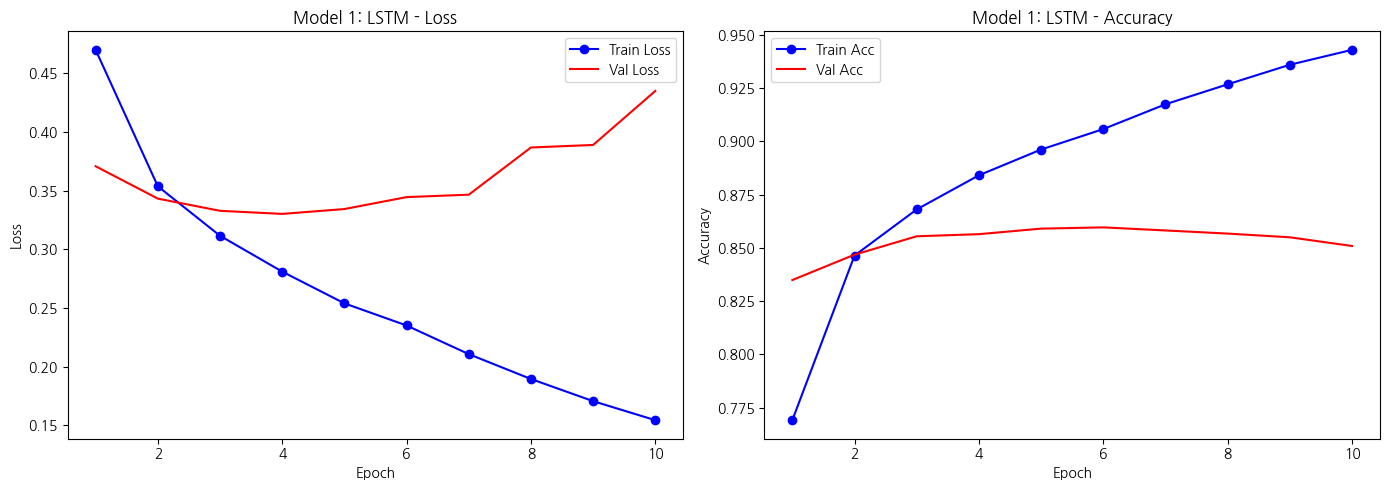

In [21]:
# 학습 곡선 시각화
plot_history(history_lstm, title='Model 1: LSTM')

자체 학습 임베딩 LSTM 모델의 경우, 2 에폭이 학습의 최적점인 듯하다

In [22]:
# 테스트 평가
acc_lstm = evaluate_model(model_lstm, test_loader_pre)

Test Loss: 0.4484, Test Accuracy: 0.8486


#### 모델 2: 1-D CNN

In [23]:
# DataLoader 구성 (post 패딩 → CNN용)
train_loader_post = DataLoader(
    TensorDataset(X_train_post_t, y_train_t), batch_size=batch_size, shuffle=True)
val_loader_post = DataLoader(
    TensorDataset(X_val_post, y_val_t), batch_size=batch_size, shuffle=False)
test_loader_post = DataLoader(
    TensorDataset(X_test_post_t, y_test_t), batch_size=batch_size, shuffle=False)

# 모델 생성
model_cnn = CNNModel(vocab_size, embedding_dim)
print(model_cnn)

CNNModel(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (conv3): Conv1d(128, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (conv4): Conv1d(128, 64, kernel_size=(4,), stride=(1,), padding=(1,))
  (conv5): Conv1d(128, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=192, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)


In [24]:
# CNN 모델 학습
history_cnn = train_model(model_cnn, train_loader_post, val_loader_post, epochs=10, lr=0.001)

Epoch  1/10 | Train Loss: 0.5003, Acc: 0.7458 | Val Loss: 0.3904, Acc: 0.8251
Epoch  2/10 | Train Loss: 0.3856, Acc: 0.8270 | Val Loss: 0.3543, Acc: 0.8442
Epoch  3/10 | Train Loss: 0.3417, Acc: 0.8519 | Val Loss: 0.3400, Acc: 0.8531
Epoch  4/10 | Train Loss: 0.3156, Acc: 0.8662 | Val Loss: 0.3321, Acc: 0.8558
Epoch  5/10 | Train Loss: 0.2947, Acc: 0.8769 | Val Loss: 0.3304, Acc: 0.8580
Epoch  6/10 | Train Loss: 0.2770, Acc: 0.8858 | Val Loss: 0.3267, Acc: 0.8609
Epoch  7/10 | Train Loss: 0.2622, Acc: 0.8930 | Val Loss: 0.3364, Acc: 0.8562
Epoch  8/10 | Train Loss: 0.2472, Acc: 0.8989 | Val Loss: 0.3333, Acc: 0.8608
Epoch  9/10 | Train Loss: 0.2351, Acc: 0.9052 | Val Loss: 0.3384, Acc: 0.8592
Epoch 10/10 | Train Loss: 0.2235, Acc: 0.9101 | Val Loss: 0.3474, Acc: 0.8582


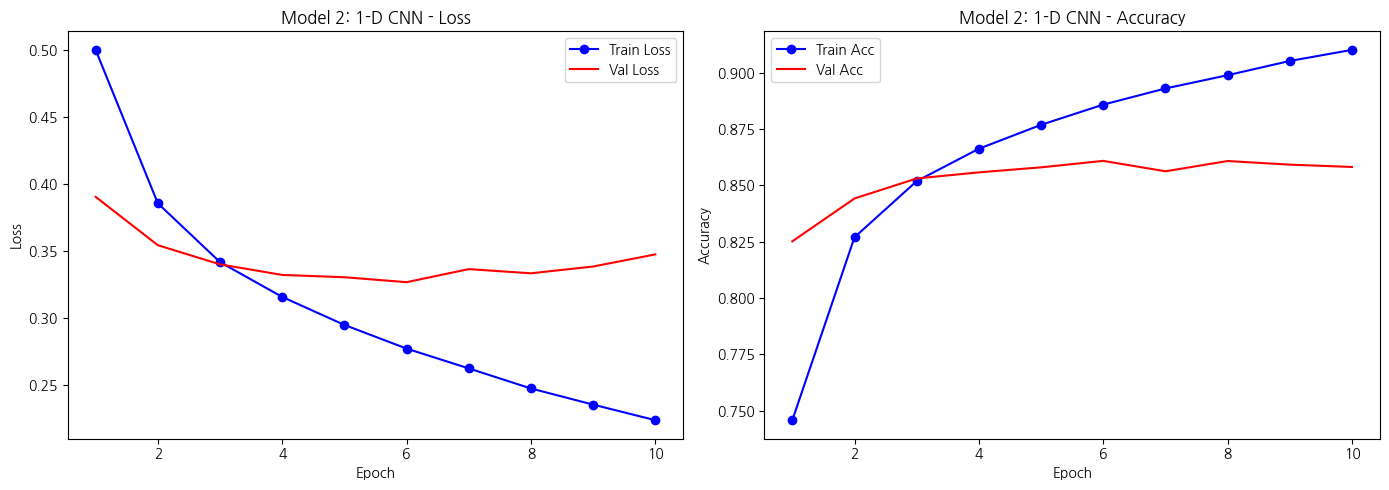

In [25]:
plot_history(history_cnn, title='Model 2: 1-D CNN')

자체 학습 임베딩 1-D CNN 모델의 경우, 3 에폭이 학습의 최적점인 듯하다

In [26]:
acc_cnn = evaluate_model(model_cnn, test_loader_post)

Test Loss: 0.3515, Test Accuracy: 0.8568


#### 모델 3: Bidirectional LSTM

In [27]:
# 모델 생성
model_bilstm = BiLSTMModel(vocab_size, embedding_dim)
print(model_bilstm)

BiLSTMModel(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (lstm): LSTM(128, 64, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=128, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)


In [28]:
# BiLSTM 모델 학습
history_bilstm = train_model(model_bilstm, train_loader_pre, val_loader_pre, epochs=10, lr=0.001)

Epoch  1/10 | Train Loss: 0.4598, Acc: 0.7742 | Val Loss: 0.3669, Acc: 0.8381
Epoch  2/10 | Train Loss: 0.3423, Acc: 0.8505 | Val Loss: 0.3397, Acc: 0.8496
Epoch  3/10 | Train Loss: 0.2985, Acc: 0.8738 | Val Loss: 0.3281, Acc: 0.8566
Epoch  4/10 | Train Loss: 0.2645, Acc: 0.8912 | Val Loss: 0.3348, Acc: 0.8568
Epoch  5/10 | Train Loss: 0.2361, Acc: 0.9052 | Val Loss: 0.3473, Acc: 0.8572
Epoch  6/10 | Train Loss: 0.2088, Acc: 0.9183 | Val Loss: 0.3876, Acc: 0.8588
Epoch  7/10 | Train Loss: 0.1820, Acc: 0.9299 | Val Loss: 0.3991, Acc: 0.8537
Epoch  8/10 | Train Loss: 0.1580, Acc: 0.9404 | Val Loss: 0.4203, Acc: 0.8540
Epoch  9/10 | Train Loss: 0.1368, Acc: 0.9495 | Val Loss: 0.4611, Acc: 0.8506
Epoch 10/10 | Train Loss: 0.1208, Acc: 0.9558 | Val Loss: 0.5153, Acc: 0.8497


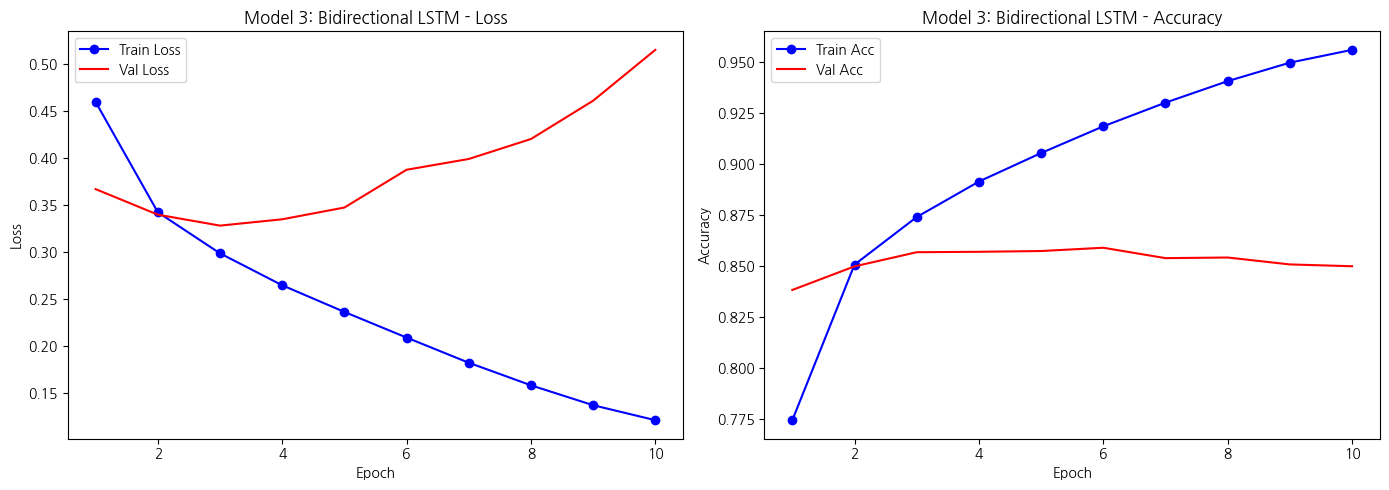

In [29]:
plot_history(history_bilstm, title='Model 3: Bidirectional LSTM')

자체 학습 임베딩 Bi-LSTM 모델의 경우도, 2 에폭이 학습의 최적점인 듯하다

In [30]:
acc_bilstm = evaluate_model(model_bilstm, test_loader_pre)

Test Loss: 0.5093, Test Accuracy: 0.8517


### 자체 학습 모델 성능 비교

In [31]:
# 자체 임베딩 모델 성능 비교 표
print('=' * 50)
print(f'{"모델":<25} {"Test Accuracy":>15}')
print('-' * 50)
print(f'{"LSTM":<25} {acc_lstm:>15.4f}')
print(f'{"1-D CNN":<25} {acc_cnn:>15.4f}')
print(f'{"Bidirectional LSTM":<25} {acc_bilstm:>15.4f}')
print('=' * 50)

모델                          Test Accuracy
--------------------------------------------------
LSTM                               0.8486
1-D CNN                            0.8568
Bidirectional LSTM                 0.8517


### 학습된 임베딩 레이어 분석

In [32]:
# --- 자체 학습 임베딩 저장 및 분석 ---
# 가장 성능이 좋았던 모델의 임베딩을 분석
best_self_model = model_cnn

# 임베딩 가중치 추출
weights = best_self_model.embedding.weight.detach().cpu().numpy()
print(f'임베딩 행렬 shape: {weights.shape}')

# gensim 형식으로 워드 벡터 파일 저장
word2vec_dir = os.path.join(os.getenv('HOME'), 'work/sentiment_classification/word2vec_emb/')
os.makedirs(word2vec_dir, exist_ok=True)
self_trained_path = os.path.join(word2vec_dir, 'self_trained_word2vec.txt')

with open(self_trained_path, 'w') as f:
    # 특수 토큰 4개(PAD, BOS, UNK, UNUSED)를 제외
    f.write(f'{vocab_size - 4} {embedding_dim}\n')
    for i in range(4, vocab_size):
        word = index_to_word[i]
        vector_str = ' '.join(map(str, weights[i]))
        f.write(f'{word} {vector_str}\n')

print('자체 학습 워드 벡터 파일 저장 완료!')

임베딩 행렬 shape: (10000, 128)
자체 학습 워드 벡터 파일 저장 완료!


In [33]:
# 자체 학습 임베딩 로드 및 유사 단어 확인
self_word_vectors = Word2VecKeyedVectors.load_word2vec_format(self_trained_path, binary=False)

# 주요 단어에 대한 유사 단어 검색
test_words = ['재밌', '최고', '별로', '감동', '연기']

print('=== 자체 학습 임베딩 유사 단어 분석 ===')
for word in test_words:
    if word in self_word_vectors:
        print(f'\n"{word}"와 유사한 단어:')
        for similar_word, score in self_word_vectors.similar_by_word(word, topn=5):
            print(f'  {similar_word:>10s} : {score:.4f}')
    else:
        print(f'\n"{word}"는 사전에 없습니다.')

=== 자체 학습 임베딩 유사 단어 분석 ===

"재밌"와 유사한 단어:
         사형수 : 0.3281
         검색어 : 0.3243
          당장 : 0.3015
      !!!!!! : 0.2932
          바꾸 : 0.2877

"최고"와 유사한 단어:
          사단 : 0.3561
         이나마 : 0.3382
          만점 : 0.3282
          깨끗 : 0.3199
           닫 : 0.2986

"별로"와 유사한 단어:
        브레이크 : 0.3417
         이수근 : 0.3245
          볼일 : 0.3102
          세라 : 0.3050
         소고기 : 0.3033

"감동"와 유사한 단어:
          검프 : 0.3391
          to : 0.3335
          질림 : 0.3157
       필모그래피 : 0.3058
          각지 : 0.3054

"연기"와 유사한 단어:
           제 : 0.3956
         뛰어나 : 0.3341
          속지 : 0.2895
          던지 : 0.2834
          호호 : 0.2813


### 한국어 Word2Vec 사전학습 임베딩 적용

In [34]:
# --- 사전학습 한국어 Word2Vec 로드 ---
# /data 폴더의 word2vec_ko.model 활용
word2vec_path = os.path.join(data_dir, 'word2vec_ko.model')
word2vec_ko = GensimWord2Vec.load(word2vec_path)

# 사전학습 모델의 벡터 차원 확인
pretrained_dim = word2vec_ko.wv.vector_size
print(f'사전학습 Word2Vec 벡터 차원: {pretrained_dim}')
print(f'사전학습 Word2Vec 단어 수: {len(word2vec_ko.wv)}')

사전학습 Word2Vec 벡터 차원: 100
사전학습 Word2Vec 단어 수: 302960


In [35]:
# --- 사전학습 임베딩 유사 단어 분석 ---
print('=== 사전학습 Word2Vec 유사 단어 분석 ===')
for word in test_words:
    if word in word2vec_ko.wv:
        print(f'\n"{word}"와 유사한 단어:')
        for similar_word, score in word2vec_ko.wv.similar_by_word(word, topn=5):
            print(f'  {similar_word:>10s} : {score:.4f}')
    else:
        print(f'\n"{word}"는 사전학습 모델에 없습니다.')

=== 사전학습 Word2Vec 유사 단어 분석 ===

"재밌"와 유사한 단어:
         재미있 : 0.9052
          멋있 : 0.8684
          웃기 : 0.8313
          예쁘 : 0.8088
          슬프 : 0.7752

"최고"와 유사한 단어:
          역대 : 0.6544
          최다 : 0.6140
          최악 : 0.6104
          최대 : 0.6002
          최저 : 0.5937

"별로"와 유사한 단어:
          전혀 : 0.6422
         그다지 : 0.6234
           꽤 : 0.6036
         확실히 : 0.5738
          딱히 : 0.5515

"감동"와 유사한 단어:
          감격 : 0.8046
          감탄 : 0.7327
          매혹 : 0.7267
          매력 : 0.7089
          감명 : 0.7069

"연기"와 유사한 단어:
          연출 : 0.7650
          열연 : 0.6947
         캐스팅 : 0.6806
          촬영 : 0.6222
         데이트 : 0.6133


In [36]:
# --- 자체학습 vs 사전학습 임베딩 비교 ---
print('=' * 60)
print(f'{"단어":<8} | {"자체학습 Top-3":<30} | {"사전학습 Top-3":<30}')
print('-' * 60)
for word in test_words:
    self_top3 = ''
    pre_top3 = ''
    if word in self_word_vectors:
        self_top3 = ', '.join([w for w, _ in self_word_vectors.similar_by_word(word, topn=3)])
    if word in word2vec_ko.wv:
        pre_top3 = ', '.join([w for w, _ in word2vec_ko.wv.similar_by_word(word, topn=3)])
    print(f'{word:<8} | {self_top3:<30} | {pre_top3:<30}')
print('=' * 60)

단어       | 자체학습 Top-3                     | 사전학습 Top-3                    
------------------------------------------------------------
재밌       | 사형수, 검색어, 당장                   | 재미있, 멋있, 웃기                   
최고       | 사단, 이나마, 만점                    | 역대, 최다, 최악                    
별로       | 브레이크, 이수근, 볼일                  | 전혀, 그다지, 꽤                    
감동       | 검프, to, 질림                     | 감격, 감탄, 매혹                    
연기       | 제, 뛰어나, 속지                     | 연출, 열연, 캐스팅                   


In [37]:
# --- 사전학습 임베딩 매트릭스 구성 ---
# 우리 사전의 각 단어에 대해 Word2Vec 벡터를 매핑
embedding_matrix = np.random.uniform(-0.05, 0.05, (vocab_size, pretrained_dim))

matched_count = 0
for word, idx in word_to_index.items():
    if word in word2vec_ko.wv:
        embedding_matrix[idx] = word2vec_ko.wv[word]
        matched_count += 1

# PAD 토큰은 영벡터로 설정
embedding_matrix[0] = np.zeros(pretrained_dim)

print(f'사전 내 단어 중 Word2Vec 매칭된 단어: {matched_count}/{vocab_size} '
      f'({matched_count/vocab_size*100:.1f}%)')
print(f'임베딩 매트릭스 shape: {embedding_matrix.shape}')

사전 내 단어 중 Word2Vec 매칭된 단어: 9457/10000 (94.6%)
임베딩 매트릭스 shape: (10000, 100)


### Word2Vec 적용 모델 학습 및 비교

In [38]:
# 사전학습 임베딩 차원에 맞게 패딩 데이터를 재활용 (데이터는 동일, 모델만 변경)
# embedding_dim을 사전학습 벡터 차원으로 설정
pretrained_embedding_dim = pretrained_dim
print(f'사전학습 임베딩 차원: {pretrained_embedding_dim}')

사전학습 임베딩 차원: 100


#### Word2Vec + LSTM

In [39]:
model_lstm_w2v = LSTMModel(vocab_size, pretrained_embedding_dim,
                           embedding_matrix=embedding_matrix)
print(model_lstm_w2v)

history_lstm_w2v = train_model(model_lstm_w2v, train_loader_pre, val_loader_pre,
                               epochs=10, lr=0.001)

LSTMModel(
  (embedding): Embedding(10000, 100, padding_idx=0)
  (lstm): LSTM(100, 64, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)
Epoch  1/10 | Train Loss: 0.4651, Acc: 0.7778 | Val Loss: 0.3635, Acc: 0.8389
Epoch  2/10 | Train Loss: 0.3485, Acc: 0.8477 | Val Loss: 0.3304, Acc: 0.8558
Epoch  3/10 | Train Loss: 0.3093, Acc: 0.8685 | Val Loss: 0.3189, Acc: 0.8641
Epoch  4/10 | Train Loss: 0.2851, Acc: 0.8808 | Val Loss: 0.3189, Acc: 0.8644
Epoch  5/10 | Train Loss: 0.2648, Acc: 0.8899 | Val Loss: 0.3182, Acc: 0.8666
Epoch  6/10 | Train Loss: 0.2497, Acc: 0.8978 | Val Loss: 0.3331, Acc: 0.8650
Epoch  7/10 | Train Loss: 0.2334, Acc: 0.9050 | Val Loss: 0.3339, Acc: 0.8652
Epoch  8/10 | Train Loss: 0.2205, Acc: 0.9114 | Val Loss: 0.3518, Acc: 0.8664
Epoch  9/10 | Train Loss: 0.2060, Acc: 0.9187 | Val Loss: 0.3580, Acc: 0.8640
Ep

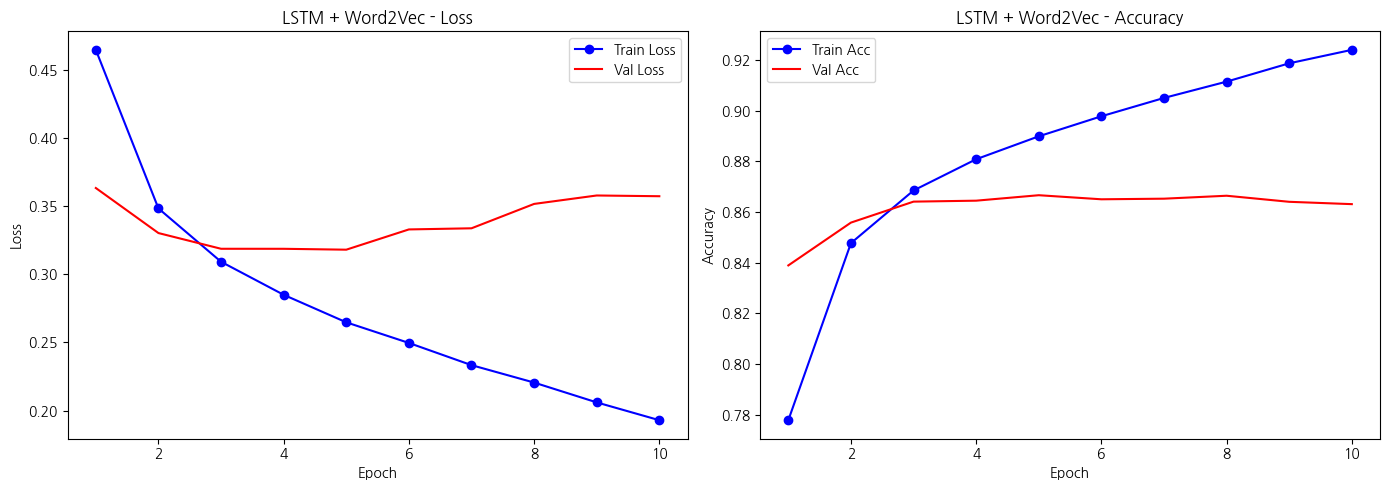

Test Loss: 0.3663, Test Accuracy: 0.8585


In [40]:
plot_history(history_lstm_w2v, title='LSTM + Word2Vec')
acc_lstm_w2v = evaluate_model(model_lstm_w2v, test_loader_pre)

#### Word2Vec + 1-D CNN

In [41]:
model_cnn_w2v = CNNModel(vocab_size, pretrained_embedding_dim,
                         embedding_matrix=embedding_matrix)

history_cnn_w2v = train_model(model_cnn_w2v, train_loader_post, val_loader_post,
                              epochs=10, lr=0.001)

Epoch  1/10 | Train Loss: 0.5167, Acc: 0.7402 | Val Loss: 0.4033, Acc: 0.8204
Epoch  2/10 | Train Loss: 0.3924, Acc: 0.8233 | Val Loss: 0.3526, Acc: 0.8462
Epoch  3/10 | Train Loss: 0.3483, Acc: 0.8482 | Val Loss: 0.3316, Acc: 0.8538
Epoch  4/10 | Train Loss: 0.3227, Acc: 0.8603 | Val Loss: 0.3278, Acc: 0.8560
Epoch  5/10 | Train Loss: 0.3061, Acc: 0.8692 | Val Loss: 0.3210, Acc: 0.8592
Epoch  6/10 | Train Loss: 0.2913, Acc: 0.8775 | Val Loss: 0.3169, Acc: 0.8627
Epoch  7/10 | Train Loss: 0.2799, Acc: 0.8813 | Val Loss: 0.3174, Acc: 0.8622
Epoch  8/10 | Train Loss: 0.2690, Acc: 0.8870 | Val Loss: 0.3156, Acc: 0.8639
Epoch  9/10 | Train Loss: 0.2606, Acc: 0.8909 | Val Loss: 0.3217, Acc: 0.8639
Epoch 10/10 | Train Loss: 0.2513, Acc: 0.8958 | Val Loss: 0.3219, Acc: 0.8654


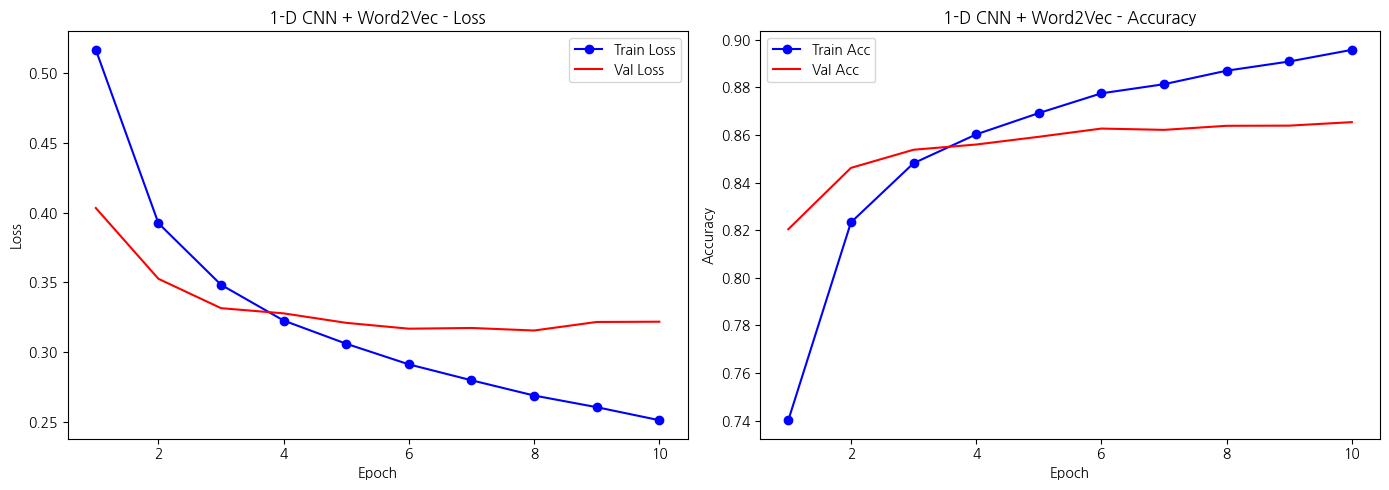

Test Loss: 0.3323, Test Accuracy: 0.8606


In [42]:
plot_history(history_cnn_w2v, title='1-D CNN + Word2Vec')
acc_cnn_w2v = evaluate_model(model_cnn_w2v, test_loader_post)

#### Word2Vec + Bidirectional LSTM

In [43]:
model_bilstm_w2v = BiLSTMModel(vocab_size, pretrained_embedding_dim,
                               embedding_matrix=embedding_matrix)

history_bilstm_w2v = train_model(model_bilstm_w2v, train_loader_pre, val_loader_pre,
                                 epochs=10, lr=0.001)

Epoch  1/10 | Train Loss: 0.4542, Acc: 0.7822 | Val Loss: 0.3583, Acc: 0.8398
Epoch  2/10 | Train Loss: 0.3361, Acc: 0.8544 | Val Loss: 0.3326, Acc: 0.8563
Epoch  3/10 | Train Loss: 0.2968, Acc: 0.8744 | Val Loss: 0.3139, Acc: 0.8620
Epoch  4/10 | Train Loss: 0.2717, Acc: 0.8868 | Val Loss: 0.3195, Acc: 0.8648
Epoch  5/10 | Train Loss: 0.2489, Acc: 0.8969 | Val Loss: 0.3267, Acc: 0.8664
Epoch  6/10 | Train Loss: 0.2290, Acc: 0.9072 | Val Loss: 0.3271, Acc: 0.8654
Epoch  7/10 | Train Loss: 0.2102, Acc: 0.9154 | Val Loss: 0.3460, Acc: 0.8647
Epoch  8/10 | Train Loss: 0.1936, Acc: 0.9232 | Val Loss: 0.3496, Acc: 0.8615
Epoch  9/10 | Train Loss: 0.1753, Acc: 0.9319 | Val Loss: 0.3925, Acc: 0.8625
Epoch 10/10 | Train Loss: 0.1594, Acc: 0.9380 | Val Loss: 0.4312, Acc: 0.8609


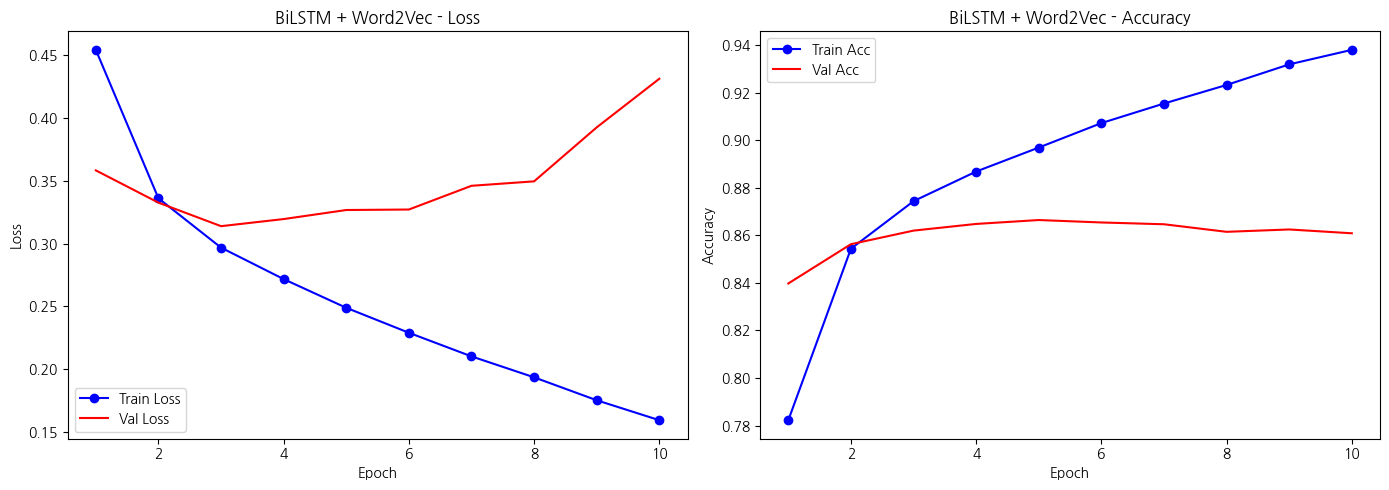

Test Loss: 0.4286, Test Accuracy: 0.8598


In [44]:
plot_history(history_bilstm_w2v, title='BiLSTM + Word2Vec')
acc_bilstm_w2v = evaluate_model(model_bilstm_w2v, test_loader_pre)

### 최종 성능 비교 및 결론

In [45]:
# === 전체 모델 성능 비교 테이블 ===
results = {
    'LSTM (자체 임베딩)':          acc_lstm,
    '1-D CNN (자체 임베딩)':       acc_cnn,
    'BiLSTM (자체 임베딩)':        acc_bilstm,
    'LSTM + Word2Vec':            acc_lstm_w2v,
    '1-D CNN + Word2Vec':         acc_cnn_w2v,
    'BiLSTM + Word2Vec':          acc_bilstm_w2v,
}

print('=' * 55)
print(f'{"모델":<30} {"Test Accuracy":>15}')
print('-' * 55)
for name, acc in results.items():
    marker = ' ✓' if acc >= 0.85 else ''
    print(f'{name:<30} {acc:>14.4f}{marker}')
print('=' * 55)
print(f'\n최고 성능 모델: {max(results, key=results.get)} '
      f'(Accuracy: {max(results.values()):.4f})')

모델                               Test Accuracy
-------------------------------------------------------
LSTM (자체 임베딩)                          0.8486
1-D CNN (자체 임베딩)                       0.8568 ✓
BiLSTM (자체 임베딩)                        0.8517 ✓
LSTM + Word2Vec                        0.8585 ✓
1-D CNN + Word2Vec                     0.8606 ✓
BiLSTM + Word2Vec                      0.8598 ✓

최고 성능 모델: 1-D CNN + Word2Vec (Accuracy: 0.8606)


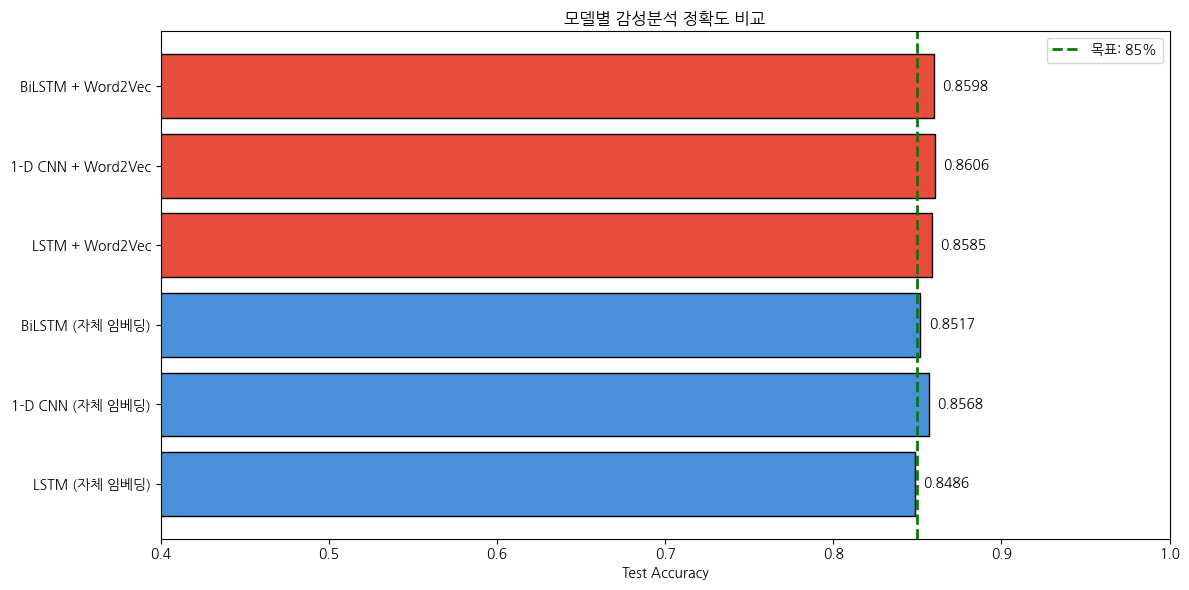

In [46]:
# 성능 비교 바 차트
plt.figure(figsize=(12, 6))
names = list(results.keys())
accs = list(results.values())

# 자체 임베딩 vs Word2Vec 색상 구분
colors = ['#4A90D9' if 'Word2Vec' not in n else '#E74C3C' for n in names]
bars = plt.barh(names, accs, color=colors, edgecolor='black')

# 85% 기준선
plt.axvline(x=0.85, color='green', linestyle='--', linewidth=2, label='목표: 85%')

# 각 막대에 정확도 수치 표시
for bar, acc in zip(bars, accs):
    plt.text(acc + 0.005, bar.get_y() + bar.get_height()/2,
             f'{acc:.4f}', va='center', fontsize=10)

plt.xlabel('Test Accuracy')
plt.title('모델별 감성분석 정확도 비교')
plt.legend()
plt.xlim(0.4, 1.0)
plt.tight_layout()
plt.show()

In [49]:
# 1. 전이학습 모델 중 가장 성능이 좋았던 모델
best_finetuned_model = model_cnn_w2v

# 2. 모델에서 최종 학습된 임베딩 가중치 추출
final_weights = best_finetuned_model.embedding.weight.detach().cpu().numpy()

# 3. gensim 형식으로 저장하기 위한 경로 설정
final_w2v_path = os.path.join(word2vec_dir, 'finetuned_word2vec.txt')

# 4. 파일 쓰기
with open(final_w2v_path, 'w') as f:
    f.write(f'{vocab_size - 4} {pretrained_dim}\n')
    for i in range(4, vocab_size):
        word = index_to_word[i]
        vector_str = ' '.join(map(str, final_weights[i]))
        f.write(f'{word} {vector_str}\n')

# 5. 저장된 파일을 다시 gensim으로 불러오기
final_word_vectors = Word2VecKeyedVectors.load_word2vec_format(final_w2v_path, binary=False)
print("최종 학습 모델의 임베딩 로드 완료!")

최종 학습 모델의 임베딩 로드 완료!


In [51]:
test_words = ['재밌', '최고', '별로', '감동', '연기']

print('=' * 95)
print(f'{"단어":<8} | {"① 자체학습 (독학)":<25} | {"② 원본 W2V (백과사전)":<25} | {"③ 최종 모델 (적응 완료)":<25}')
print('-' * 95)

for word in test_words:
    self_top3 = "N/A"
    origin_top3 = "N/A"
    final_top3 = "N/A"
    
    # ① 자체학습 모델 결과
    if word in self_word_vectors:
        self_top3 = ', '.join([w for w, _ in self_word_vectors.similar_by_word(word, topn=3)])
    
    # ② 순수 사전학습(원본) 결과
    if word in word2vec_ko.wv:
        origin_top3 = ', '.join([w for w, _ in word2vec_ko.wv.similar_by_word(word, topn=3)])
        
    # ③ 전이학습 후 미세 조정(Fine-tuning)된 결과
    if word in final_word_vectors:
        final_top3 = ', '.join([w for w, _ in final_word_vectors.similar_by_word(word, topn=3)])
        
    print(f'{word:<8} | {self_top3:<28} | {origin_top3:<28} | {final_top3:<28}')

print('=' * 95)

단어       | ① 자체학습 (독학)               | ② 원본 W2V (백과사전)           | ③ 최종 모델 (적응 완료)          
-----------------------------------------------------------------------------------------------
재밌       | 사형수, 검색어, 당장                 | 재미있, 멋있, 웃기                  | 재미있, 멋있, 웃기                 
최고       | 사단, 이나마, 만점                  | 역대, 최다, 최악                   | 역대, 올해, 최대                  
별로       | 브레이크, 이수근, 볼일                | 전혀, 그다지, 꽤                   | 전혀, 그다지, 딱히                 
감동       | 검프, to, 질림                   | 감격, 감탄, 매혹                   | 감격, 감탄, 매혹                  
연기       | 제, 뛰어나, 속지                   | 연출, 열연, 캐스팅                  | 연출, 열연, 캐스팅                 


### 회고

우선, LSTM, 1D CNN, Bi LSTM 세가지 모델을 자체학습시키고 학습의 결과를 확인해본 결과. 
   - 세 모델 모두 2~3에폭 정도가 학습의 최적점임을 확인할 수 있었다
   - 또한, 세 모델 모두 84%이상의 test accuracy를 보였고 그 중 가장 높은 정확도를 보인 것은 1D CNN이었다.

실습을 할 때 사용했던 총 50000개의 IMDB 데이터셋과 비교했을 때,  
이번에 이용한 NSMC 데이터셋은 총 200,000개로 훨씬 많아서인지 자체학습 임베딩 모델의 정확도가 이미 85% 정도를 보였다.

자체 학습 임베딩 모델과 사전학습 Word2Vec 적용 모델의 정확도 차이는
   - 분명 자체 학습 임베딩보다 사전학습 적용한 경우가 더 높은 정확도를 보였지만,
   - 그 차이는 미미했다

하지만 **similarity 유사 단어 찾기를 활용하여 비교했을 때에는**
   - 자체 학습 임베딩 모델은 성능이 좋지 않았고
   - 사전 학습 임베딩 적용 모델이 훨씬 좋은 성능을 보였다
      - 사전 학습 임베딩 자체를 활용했을 때와 거의 유사

왜 이런 결과가 나왔을까?
- 사전학습 적용 모델을 적용했을 때 드라마틱한 성능 향상이 발생하지 않은 이유?
   - 85%는 이미 상당히 높은 정확도라서 더 오를 수 없어서? (Ceiling Effect)
   - NSMC 데이터는 사람들이 작성한 리뷰이고 일반적인 텍스트 데이터로 만들어진 Word2Vec과 도메인에 차이가 있어서? (Domain Mismatch)
   - 긍정, 부정 두가지로 분류를 학습하기엔 이미 NSMC 데이터 자체가 충분히 많은 양이어서? (Data Saturation)
- 모델의 정확도는 85%로 유사하지만 막상 유사 단어 찾기를 했을 때에는 성능이 전혀 다른 이유? 
   - 자체 학습의 경우 분류에만 집중해서 단어 사이의 관계보다는 NSMC 데이터를 외웠을 가능성?
   - 사전학습의 경우 단어 사이의 관계가 정립된 상태이기 때문에

텍스트 분류 모델의 경우 정확도와 단어의 의미를 이해하는 것, 임베딩은 별개의 문제라는 것을 확인할 수 있었다